# Sea ice: CAMulator checkpoints vs ground truth

Compares monthly coupler ice fraction from a CAMulator + POP2 + CICE5 checkpoint
against Will's ground-truth run.

| | |
|---|---|
| checkpoint | `IFRAC` from `*.pop.h.YYYY-MM.nc`, gx1v7 curvilinear 384×320 |
| ground truth | `ICEFRAC` from Will's zarr, regular lat/lon 192×288, year 1980 |

**The checkpoint stays on its native gx1v7 grid. The reference is what gets
regridded.** The checkpoint is the field under evaluation, so interpolating it
would put regridding artifacts into the thing being judged. Every checkpoint
already shares gx1v7, so checkpoint-vs-checkpoint and checkpoint-vs-reference are
both a plain cell-for-cell subtract, and POP's own `TAREA` stays the area weight
for every number.

**Kernel:** needs `xesmf` — use `/glade/u/apps/opt/conda/envs/npl-2025b/bin/python`,
not the default JupyterHub one.


In [2]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
from ice_ens import data, metrics, plot_poles, regrid

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load

Both are read in place from scratch — nothing is copied.

Will has **one zarr store per calendar year, 1980–2014**; the checkpoints run
1980–1990, so that overlap is the usable window. `load_checkpoint` and
`load_truth` take the same `years` shorthand — a bare int, a list, or two values
read as an inclusive range — so ask both sides for the same window in the same
words. `data.truth_years()` lists what exists.

> Give both sides the same `years`. If they differ, the arithmetic in `metrics`
> silently falls back to the overlap rather than complaining.

`load_truth` brings `LANDFRAC` along as well; it is needed to undo CAM's coastal
land dilution on the way across. It is fixed in time, so it is read once no
matter how many years you ask for.


In [12]:
CASE = "ck33"  # <- the checkpoint
YEARS = [1980]  # <- the window: two values = inclusive range,
#    or a list of years, or a bare int
YEAR = 1980  # <- the single year the maps are drawn for

model = data.load_checkpoint(CASE, years=YEARS)
truth = data.load_truth(years=YEARS)

print(model.sizes)
print(truth.sizes)
print("truth stores available:", data.truth_years()[0], "-", data.truth_years()[-1])

Frozen({'nlat': 384, 'nlon': 320, 'time': 12})
Frozen({'time': 12, 'latitude': 192, 'longitude': 288})
truth stores available: 1980 - 2014


## Is the reference finer than gx1v7?

It is not — this is worth seeing before trusting any difference map. Equivalent
cell width (√area) in the sea-ice latitudes:

| band | reference | gx1v7 |
|---|---|---|
| 60–70° | 78 km | 52 km |
| 70–80° | 62 km | 41 km |
| 80–90° | 36 km | 34 km |

So the reference is ~1.5× coarser than gx1v7 through the marginal ice zone. That
does not make the direction wrong — a conservative map coarse→fine preserves the
area integral exactly and invents no ice — but the reference panel will look blocky
and the *effective* resolution of any difference is the reference's, not gx1v7's.
Fine structure in a difference map is the model's own; fine structure in the
reference is not there to be resolved.


## Regrid the reference onto the checkpoint's gx1v7 grid

Two methods, and they are not interchangeable.

- `bilinear` — centres only, builds in a second. Fine for a first-look difference
  map. It does **not** preserve an area integral, so never total an area off it.
- `conservative` — preserves the area integral, needs cell corners on both grids.
  This is the one for any ice-area or ice-extent number.

Weight files are written once to `weights/` under this repo (on `work`, not scratch,
so a purge cannot take them) and reused afterwards. The regridder only reads the
checkpoint for its grid, and all checkpoints share gx1v7 — so build it once and pass
it to every case.

The weights depend only on the two *grids*, so the same pair of files serves
every year and every checkpoint.


In [13]:
# quick look
bilinear = regrid.build_regridder(truth, model, method="bilinear")

# the one that gives trustworthy numbers
conservative = regrid.build_regridder(truth, model, method="conservative")

ref = regrid.to_model_grid(truth, model, conservative)
ref

/glade/u/apps/opt/conda/envs/npl-2025b/lib/python3.12/site-packages/xesmf/frontend.py:716: UserWarning: Using dimensions ('latitude', 'longitude') from data variable ICEFRAC as the horizontal dimensions for the regridding.
  warnings.warn(
/glade/u/apps/opt/conda/envs/npl-2025b/lib/python3.12/site-packages/xesmf/frontend.py:716: UserWarning: Using dimensions ('latitude', 'longitude') from data variable LANDFRAC as the horizontal dimensions for the regridding.
  warnings.warn(


<xarray.Dataset> Size: 29MB
Dimensions:  (time: 12, nlat: 384, nlon: 320)
Coordinates:
    year     (time) int32 48B 1980 1980 1980 1980 1980 ... 1980 1980 1980 1980
    ULONG    (nlat, nlon) float64 983kB 321.1 322.3 323.4 ... 319.2 319.6 320.0
    ULAT     (nlat, nlon) float64 983kB -78.95 -78.95 -78.95 ... 72.41 72.41
    TLONG    (nlat, nlon) float64 983kB 320.6 321.7 322.8 ... 318.9 319.4 319.8
    TLAT     (nlat, nlon) float64 983kB -79.22 -79.22 -79.22 ... 72.19 72.19
    month    (time) int32 48B 1 2 3 4 5 6 7 8 9 10 11 12
  * time     (time) object 96B 1980-01-15 00:00:00 ... 1980-12-15 00:00:00
Dimensions without coordinates: nlat, nlon
Data variables:
    IFRAC    (time, nlat, nlon) float64 12MB nan nan nan nan ... nan nan nan nan
    ICEFRAC  (time, nlat, nlon) float64 12MB 0.06198 0.08575 0.07039 ... 0.0 0.0
    SEAFRAC  (nlat, nlon) float64 983kB 0.06244 0.08646 0.07109 ... 0.0 0.0 0.0
    TAREA    (nlat, nlon) float64 983kB 1.125e+13 1.125e+13 ... 7.432e+12
Attributes:
    label:    ground truth
    grid:     gx1v7 POP T-grid
    years:    1980
    regrid:   conservative (xESMF/ESMF), reference -> gx1v7

### The two fields it returns

- `IFRAC` — ice fraction of the **sea** part of the cell, POP's convention. This is
  what subtracts cell-for-cell against the checkpoint's `IFRAC`. Plot and difference
  this one.
- `ICEFRAC` — the raw regridded field, ice over **total** cell area, CAM's
  convention. Area-conserving, so this is what the conservation check weighs.

The difference between them is CAM's coastal land dilution, divided back out with
the reference's own sea fraction `1 - LANDFRAC` regridded through the same map.

> Not `OCNFRAC`. In CAM `LANDFRAC + OCNFRAC + ICEFRAC = 1`, so `OCNFRAC` is the
> *open* ocean and goes to zero under the pack. Dividing by it deletes the solid
> ice rather than un-diluting it.


### Did it conserve the ice?

`relative_error` should sit around `-4e-4`. That residue is POP's own `TAREA`
disagreeing slightly with the area implied by its cell corners, not a regridding
error. Percent-level values would mean something is wrong.

`land_fraction_of_total` is a different thing and is not an error: it is the share
of reference ice that lands on cells POP calls land. The two land masks do not
agree, and that ice is dropped from `IFRAC`. A couple of percent in summer, five in
winter.


In [14]:
check = regrid.check_conservation(truth, ref, model)
check.to_dataframe()[
    ["area_before", "area_after", "relative_error", "land_fraction_of_total"]
]

,area_before,area_after,relative_error,land_fraction_of_total
time,,,,
1980-01-15 00:00:00,1.714492e+13,1.713784e+13,-0.000413,0.047276
1980-02-15 00:00:00,1.577037e+13,1.576384e+13,-0.000414,0.052663
1980-03-15 00:00:00,1.661852e+13,1.661153e+13,-0.000420,0.053009
1980-04-15 00:00:00,1.929938e+13,1.929126e+13,-0.000421,0.046960
1980-05-15 00:00:00,2.129782e+13,2.128890e+13,-0.000419,0.038199
1980-06-15 00:00:00,2.171705e+13,2.170796e+13,-0.000419,0.030920
1980-07-15 00:00:00,2.138001e+13,2.137105e+13,-0.000419,0.026341
1980-08-15 00:00:00,2.095299e+13,2.094421e+13,-0.000419,0.022287
1980-09-15 00:00:00,2.089016e+13,2.088143e+13,-0.000418,0.021052


## Numbers

Area and extent are computed on the native grid with POP's `TAREA` — the identical
weight for both sides, which is the payoff for keeping the checkpoint native.
Everything is in millions of km².

`metrics` refuses a bilinearly regridded field, since an area integral off one is
meaningless.


In [15]:
nh = metrics.compare(model, ref, "north")
nh.to_dataframe()[
    [
        "model_area",
        "reference_area",
        "area_bias",
        "model_extent",
        "reference_extent",
        "extent_bias",
    ]
].round(3)

,model_area,reference_area,area_bias,model_extent,reference_extent,extent_bias
time,,,,,,
1980-01-15 00:00:00,13.356,13.143,0.213,14.176,13.907,0.269
1980-02-15 00:00:00,13.945,13.788,0.157,14.698,14.638,0.060
1980-03-15 00:00:00,14.430,14.169,0.261,15.316,15.112,0.205
1980-04-15 00:00:00,14.070,13.574,0.495,15.231,14.840,0.391
1980-05-15 00:00:00,12.554,11.992,0.562,14.375,14.093,0.282
1980-06-15 00:00:00,10.310,9.872,0.439,12.643,12.087,0.556
1980-07-15 00:00:00,7.509,7.760,-0.251,9.842,10.307,-0.465
1980-08-15 00:00:00,5.596,5.992,-0.396,7.574,8.153,-0.579
1980-09-15 00:00:00,6.268,5.382,0.886,7.542,7.398,0.145


In [16]:
sh = metrics.compare(model, ref, "south")
sh.to_dataframe()[
    [
        "model_area",
        "reference_area",
        "area_bias",
        "model_extent",
        "reference_extent",
        "extent_bias",
    ]
].round(3)

,model_area,reference_area,area_bias,model_extent,reference_extent,extent_bias
time,,,,,,
1980-01-15 00:00:00,4.691,3.990,0.702,8.837,7.525,1.311
1980-02-15 00:00:00,2.149,1.964,0.185,3.445,3.012,0.433
1980-03-15 00:00:00,2.688,2.428,0.260,4.319,3.741,0.578
1980-04-15 00:00:00,6.945,5.714,1.231,8.955,7.553,1.402
1980-05-15 00:00:00,10.937,9.299,1.638,12.561,11.151,1.410
1980-06-15 00:00:00,13.575,11.838,1.738,15.242,13.785,1.457
1980-07-15 00:00:00,15.237,13.611,1.626,17.211,15.814,1.398
1980-08-15 00:00:00,16.387,14.952,1.435,18.679,17.224,1.455
1980-09-15 00:00:00,16.843,15.499,1.344,19.435,18.111,1.324


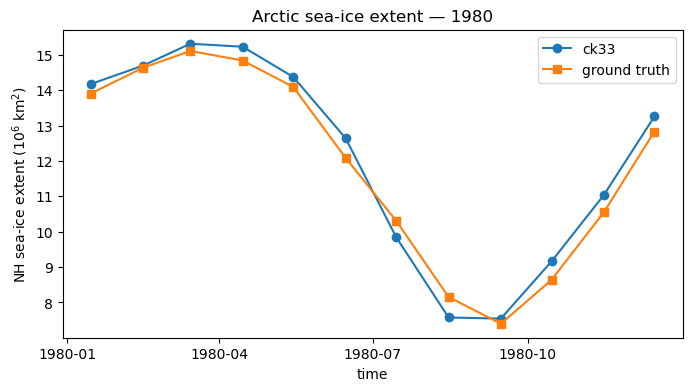

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
nh["model_extent"].plot(ax=ax, marker="o", label=f"{CASE}")
nh["reference_extent"].plot(ax=ax, marker="s", label="ground truth")
ax.set_ylabel("NH sea-ice extent (10$^6$ km$^2$)")
ax.set_title(f"Arctic sea-ice extent — {YEAR}")
ax.legend()
plt.show()

## Look at it

Both panels are on gx1v7 now, drawn with `pcolormesh` rather than contours —
contouring a tripole grid smears the seam, and the cells as-they-are is the honest
picture when the point is to judge the model's own field.

### One month, three panels


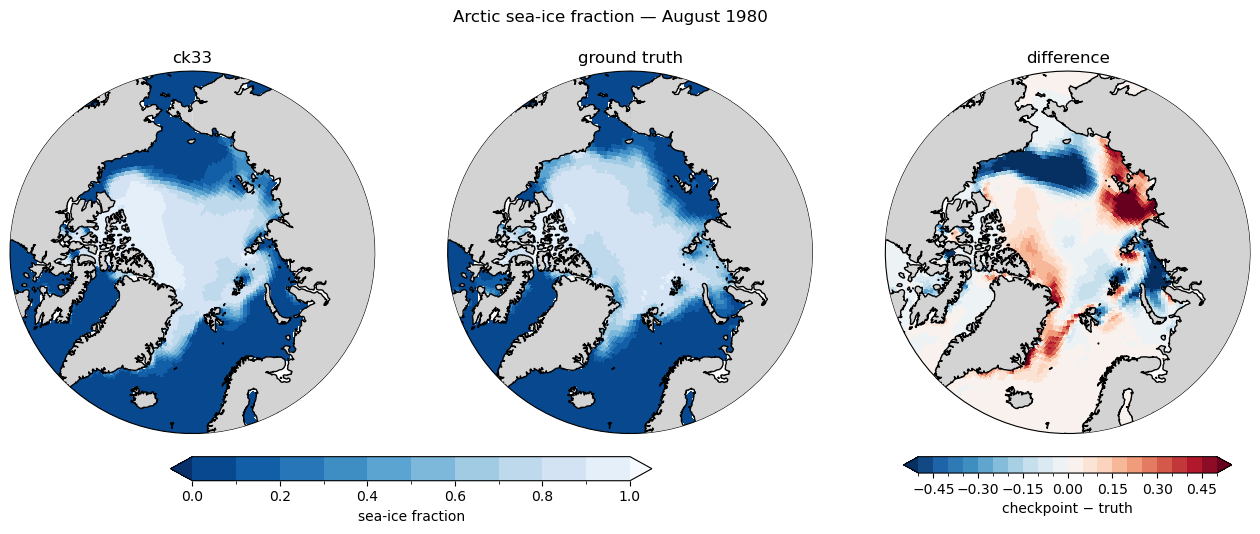

In [19]:
fig, axes = plot_poles.plot_month_compare(model, ref, YEAR, 8, "north")
plt.show()

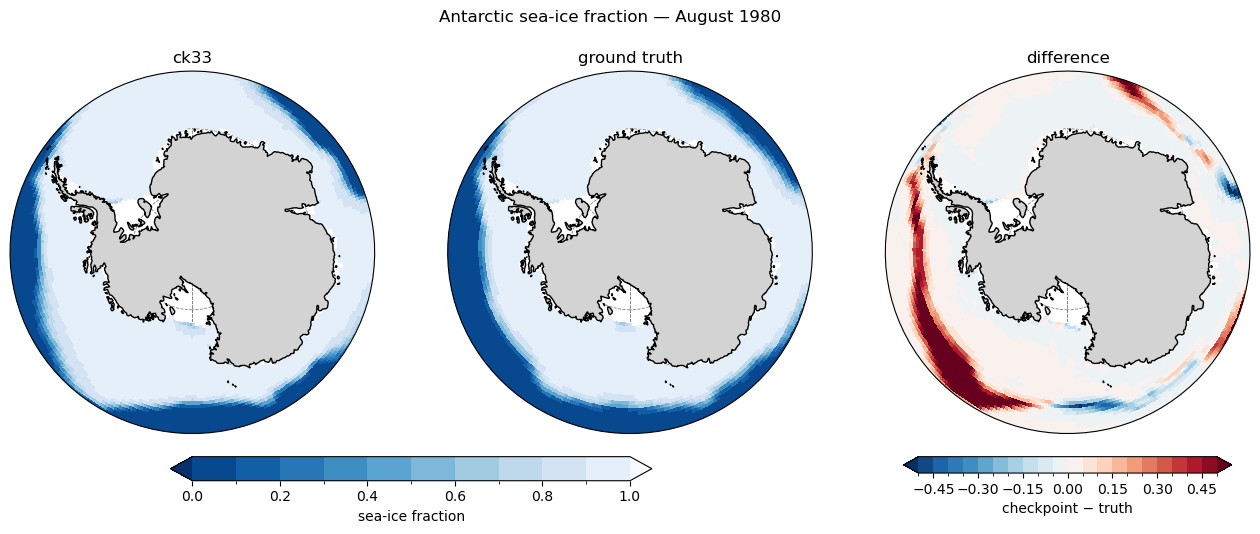

In [21]:
fig, axes = plot_poles.plot_month_compare(model, ref, YEAR, 8, "south")
plt.show()

### The whole year

Checkpoint's twelve months on top, reference's underneath. Pass `show_diff=True`
for a third row of differences.

This one takes about half a minute — it is drawing 24 maps.


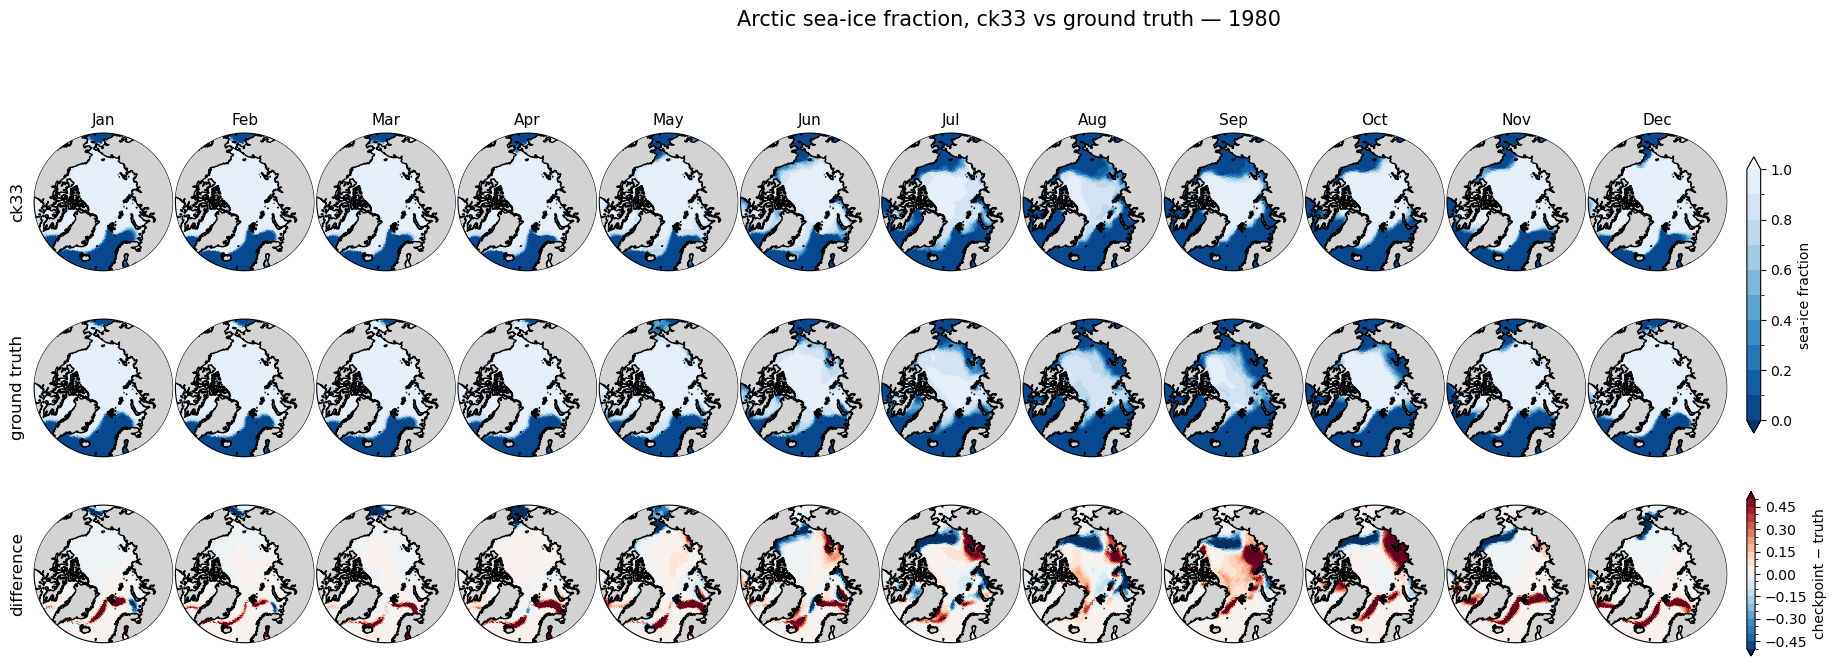

In [22]:
fig, axes = plot_poles.plot_year_compare(model, ref, YEAR, "north", show_diff=True)
plt.show()

## Write the standard set to disk

Both poles: the whole-year overview, plus a closeup of each month in `months`.
Lands in `output/<checkpoint>/figures/`.


In [23]:
written = plot_poles.save_figures(model, ref, CASE, YEAR, months=(3, 9))
print("\n".join(written))

/glade/work/tvoeller/honors_thesis/code/output/ck33/figures/arctic_year_ck33_1980.png
/glade/work/tvoeller/honors_thesis/code/output/ck33/figures/arctic_1980-03_ck33.png
/glade/work/tvoeller/honors_thesis/code/output/ck33/figures/arctic_1980-09_ck33.png
/glade/work/tvoeller/honors_thesis/code/output/ck33/figures/antarctic_year_ck33_1980.png
/glade/work/tvoeller/honors_thesis/code/output/ck33/figures/antarctic_1980-03_ck33.png
/glade/work/tvoeller/honors_thesis/code/output/ck33/figures/antarctic_1980-09_ck33.png


## Several checkpoints

The reference only has to be carried across **once** — every checkpoint is on the
same gx1v7 grid, so `ref` is reused unchanged and the loop just swaps the model.
That is the direct benefit of this direction.


In [ ]:
cases = ["ck33", "ck36", "ck64", "ck66", "ck69", "ck70"]

rows = {}
for case in cases:
    m = data.load_checkpoint(case, years=YEARS)
    plot_poles.save_figures(m, ref, case, YEAR, months=(3, 9))
    rows[case] = metrics.compare(m, ref, "north")["extent_bias"].to_pandas()
    print("done", case)

In [ ]:
import pandas as pd

pd.DataFrame(rows).round(3)  # NH extent bias by month, 10^6 km2

## Climatological bias

Multi-year means — the seasonal-mean bias maps and the hemispheric area error —
live in **`ice_climatology.ipynb`**. Everything in this notebook is one year at a
time; that one averages over a window of years.


## Turning the knobs

In `ice_ens/plot_poles.py`, near the top:

- `ICE_LEVELS` — colour bands for ice fraction, currently steps of 0.1.
- `DIFF_LEVELS` / `DIFF_CMAP` — the difference panel's scale.
- `COASTLINE` — `'50m'`; `'110m'` is coarser and barely faster.

In `ice_ens/data.py`: the input paths, `WEIGHT_DIR` and `OUTPUT_DIR`.

In `ice_ens/regrid.py`: `MIN_SEAFRAC`, below which a cell is treated as all land
rather than divided through.

In `ice_ens/metrics.py`: `EXTENT_THRESHOLD`, the 0.15 that defines extent.

## Notes

- These cases have **no `cpl.hi` files** — the coupler history stream was off.
  `IFRAC` in the POP monthly stream is the same coupler field, and is what your
  `Check_dataset.ipynb` was already reading.
- POP stamps a monthly file at the *end* of its interval (January's file says 1 Feb),
  so the month is taken from the filename, not the timestamp.
- See `ice_ens/README.md` for the rest.
